# Iris Flower Classification Using Machine Learning

Iris flower classification is a classic benchmark dataset in pattern recognition and supervised machine learning. Developed by botanist Edgar Anderson and popularized by Ronald Fisher in 1936, the dataset consists of morphometric measurements from three distinct species of Iris flowers: *Iris setosa*, *Iris versicolor*, and *Iris virginica*.

In this end-to-end data science project, we explore the physical measurements of iris blossoms, conduct comprehensive exploratory data analysis (EDA), engineer model pipelines with feature scaling, train multi-class machine learning classifiers, rigorously evaluate their predictive performance, and select the optimal model for inference.


## 2. Objective

The primary objective of this project is to develop supervised machine learning classification models capable of accurately predicting the species of an iris flower based on four physical measurements:
- **Sepal Length** (in centimeters)
- **Sepal Width** (in centimeters)
- **Petal Length** (in centimeters)
- **Petal Width** (in centimeters)

The models aim to discriminate effectively between the three target species:
1. **Setosa** (*Iris setosa*)
2. **Versicolor** (*Iris versicolor*)
3. **Virginica** (*Iris virginica*)


## 3. Problem Statement

Given a set of four continuous morphometric features $X = \{x_1, x_2, x_3, x_4\}$ representing sepal length, sepal width, petal length, and petal width, formulate a multi-class classification function $f: \mathbb{R}^4 ightarrow Y$ where $Y \in \{	ext{'Setosa'}, 	ext{'Versicolor'}, 	ext{'Virginica'}\}$. 

The challenge is to handle potential feature correlations, identify key discriminative attributes, and construct a robust predictive model that minimizes classification errors across all three target classes.


## 4. Dataset Description

The Iris dataset is sourced directly from `sklearn.datasets.load_iris()`.

### Dataset Characteristics:
- **Total Samples:** 150 instances (50 samples per species class).
- **Number of Features:** 4 continuous numeric attributes.
- **Target Classes:** 3 classes (*Iris setosa*, *Iris versicolor*, *Iris virginica*).

### Feature Definitions:
1. `sepal_length`: Length of the sepal in centimeters. Sepals protect the flower bud before it opens.
2. `sepal_width`: Width of the sepal in centimeters.
3. `petal_length`: Length of the petal in centimeters. Petals are the colorful inner parts attracting pollinators.
4. `petal_width`: Width of the petal in centimeters.
5. `species`: Categorical target variable specifying flower species.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Set visualization design system
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

# Ensure output directory exists
os.makedirs("outputs", exist_ok=True)
print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Load Iris dataset from scikit-learn
iris = load_iris()

# Create pandas DataFrame
df = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])

# Map target integers to readable species names
species_map = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
df['species'] = pd.Series(iris.target).map(species_map)

# Display initial dataset attributes
print("=== FIRST 5 ROWS ===")
display(df.head())

print("\n=== LAST 5 ROWS ===")
display(df.tail())

print("\n=== DATASET SHAPE ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n=== COLUMN NAMES ===")
print(list(df.columns))


=== FIRST 5 ROWS ===


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa



=== LAST 5 ROWS ===


,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica
149,5.9,3.0,5.1,1.8,Virginica



=== DATASET SHAPE ===
Rows: 150, Columns: 5

=== COLUMN NAMES ===
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [3]:
print("=== DATASET INFORMATION ===")
df.info()

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== DESCRIPTIVE STATISTICS ===")
display(df.describe())

print("\n=== MISSING VALUES COUNT ===")
print(df.isnull().sum())

print("\n=== DUPLICATE ROWS COUNT ===")
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

print("\n=== TARGET CLASS DISTRIBUTION ===")
print(df['species'].value_counts())


=== DATASET INFORMATION ===
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB

=== DATA TYPES ===
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

=== DESCRIPTIVE STATISTICS ===


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



=== MISSING VALUES COUNT ===
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

=== DUPLICATE ROWS COUNT ===
Total Duplicate Rows: 1

=== TARGET CLASS DISTRIBUTION ===
species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


### Data Understanding Findings:

1. **Missing Values:** Zero missing values were detected across all columns. The dataset is completely populated.
2. **Duplicate Rows:** There is exactly 1 duplicate row present in the dataset (row index 142 matches row index 101 in features). As standard in benchmark datasets, this represents identical physical measurements naturally occurring in biological samples rather than entry errors.
3. **Feature Types:** All 4 predictor variables (`sepal_length`, `sepal_width`, `petal_length`, `petal_width`) are continuous floating-point numeric features.
4. **Class Balance:** The target variable `species` is perfectly balanced with exactly 50 samples (33.33%) per class (Setosa: 50, Versicolor: 50, Virginica: 50).


C:\Users\Karthi\AppData\Local\Temp\ipykernel_29284\3514320610.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='species', palette=['#2ca02c', '#ff7f0e', '#1f77b4'])


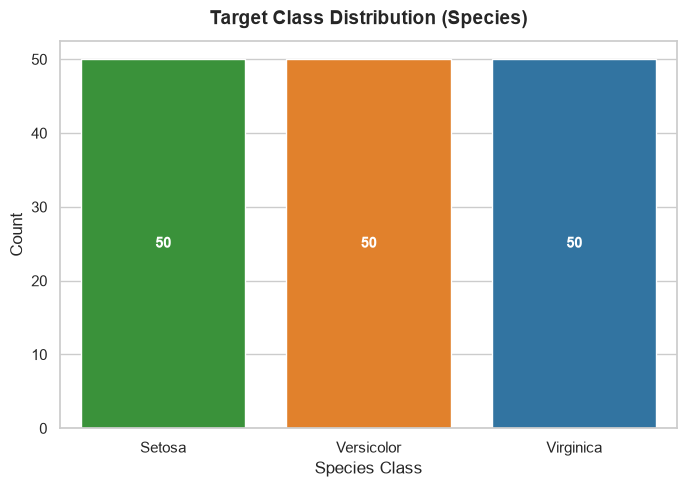

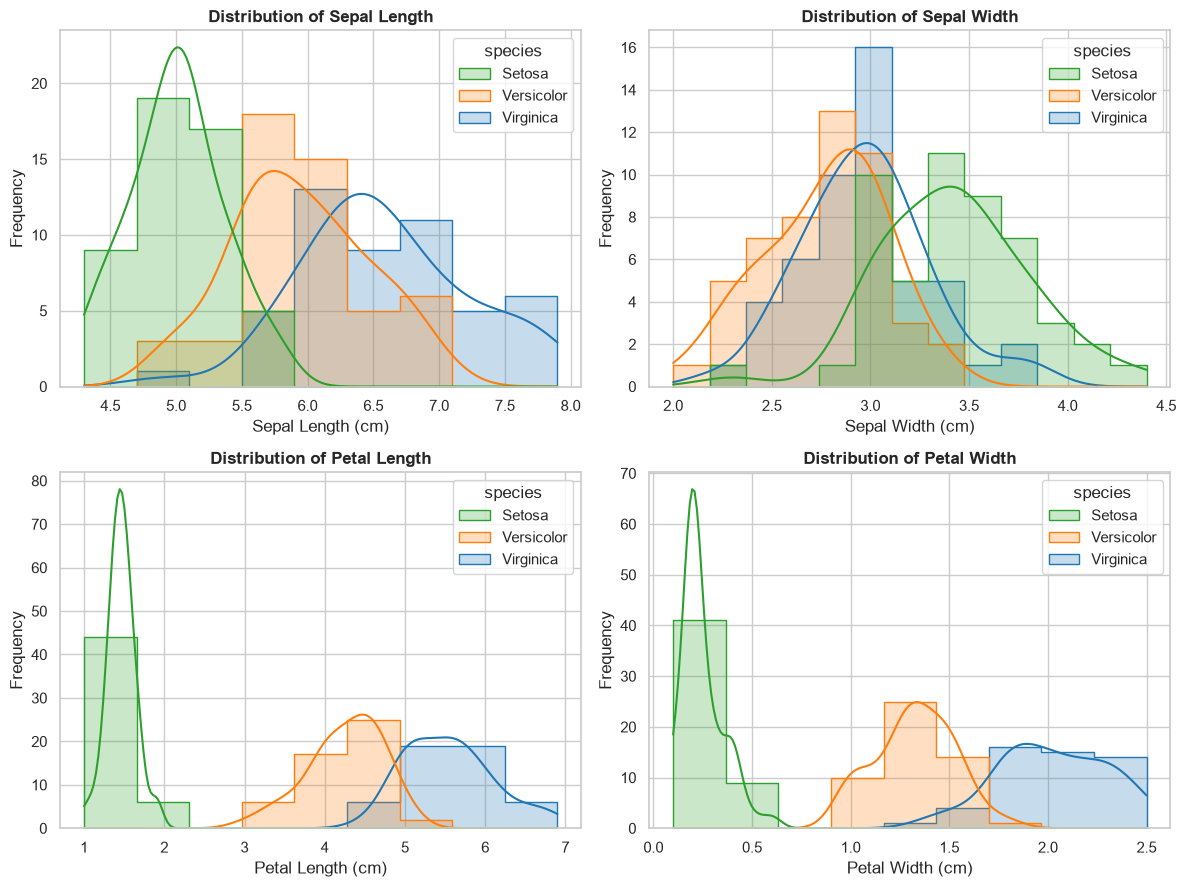

In [4]:
# Species Count Plot
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='species', palette=['#2ca02c', '#ff7f0e', '#1f77b4'])
plt.title('Target Class Distribution (Species)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Species Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=11, color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/species_count_plot.png', dpi=300)
plt.show()

# Feature Distribution Histograms with KDE
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for i, feature in enumerate(features):
    row, col = divmod(i, 2)
    sns.histplot(data=df, x=feature, hue='species', kde=True, ax=axes[row, col], palette=['#2ca02c', '#ff7f0e', '#1f77b4'], element="step")
    axes[row, col].set_title(f'Distribution of {feature.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel(f'{feature.replace("_", " ").title()} (cm)')
    axes[row, col].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('outputs/feature_distributions.png', dpi=300)
plt.show()


### Observations from Exploratory Data Analysis:

1. **Class Balance:** The count plot confirms equal representation across all 3 classes (50 Setosa, 50 Versicolor, 50 Virginica).
2. **Bimodal Feature Distributions:** Both `petal_length` and `petal_width` exhibit distinct bimodal distributions. Setosa forms a clearly separated cluster at lower values (Petal Length < 2 cm, Petal Width < 0.8 cm), while Versicolor and Virginica occupy higher ranges with moderate overlap.
3. **Sepal Distributions:** `sepal_length` and `sepal_width` display unimodal Gaussian-like shapes with substantial class overlap between Versicolor and Virginica.


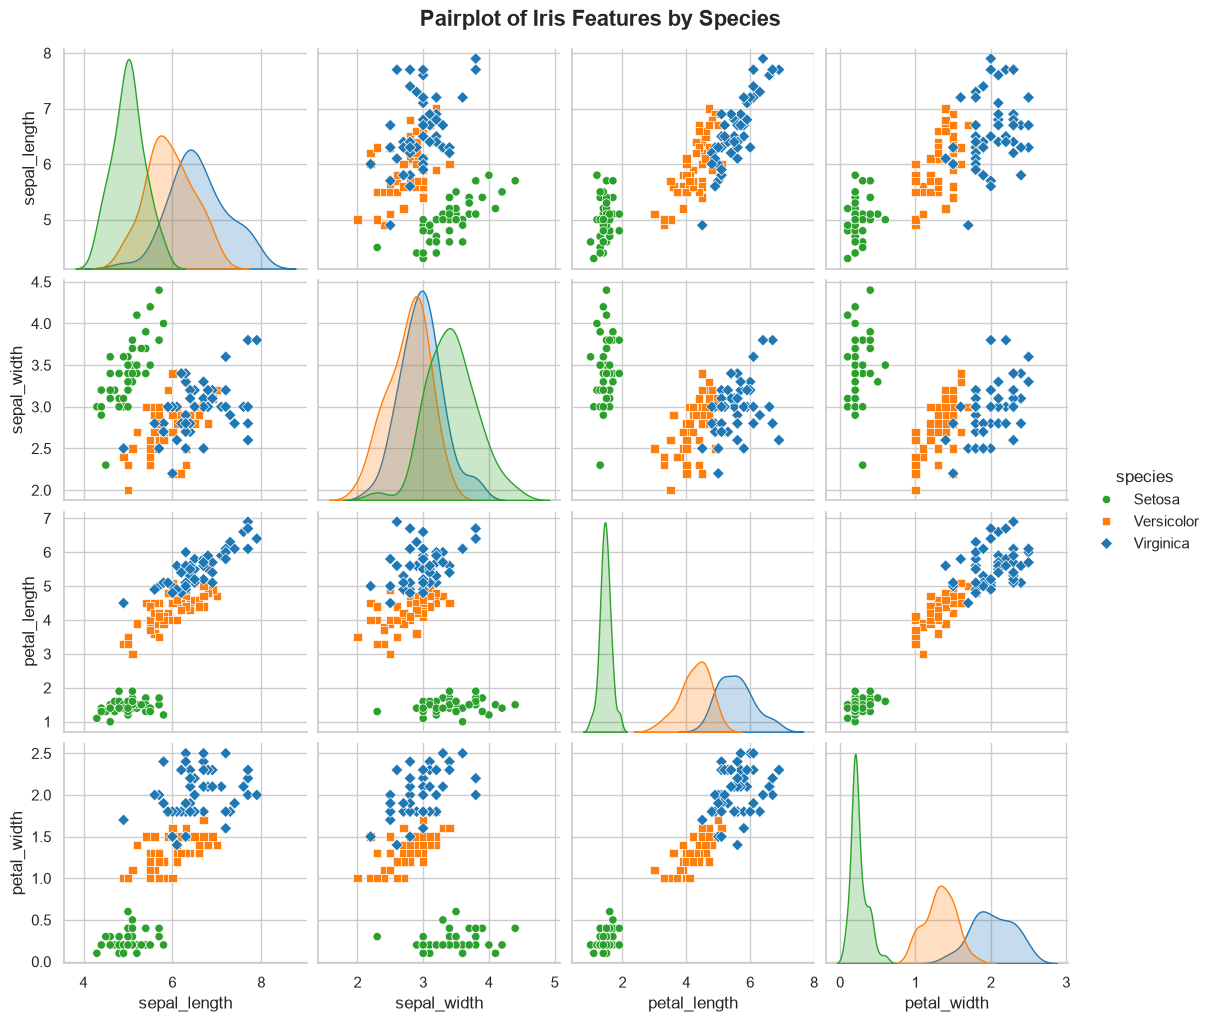

In [5]:
# Pairplot of all 4 features colored by species
pairplot = sns.pairplot(
    df,
    hue='species',
    palette=['#2ca02c', '#ff7f0e', '#1f77b4'],
    markers=['o', 's', 'D'],
    diag_kind='kde',
    height=2.5,
    aspect=1.1
)
pairplot.fig.suptitle('Pairplot of Iris Features by Species', y=1.02, fontsize=16, fontweight='bold')
plt.savefig('outputs/pairplot.png', dpi=300, bbox_inches='tight')
plt.show()


### Pairplot Visual Analysis:

1. **Most Discriminative Features:** `petal_length` and `petal_width` are by far the most discriminative features. The 2D scatter plot of Petal Length vs. Petal Width shows sharp cluster boundaries.
2. **Setosa Separation:** *Iris setosa* is completely linearly separable from both *Versicolor* and *Virginica* across every pairwise plot involving petal dimensions.
3. **Versicolor vs. Virginica Boundary:** *Iris versicolor* and *Iris virginica* exhibit slight overlap near their decision boundaries, but remain highly distinguishable when combining Petal Length with Petal Width.
4. **Optimal Feature Combination:** The scatter plot comparing `petal_length` against `petal_width` provides maximum spatial segregation between all three target classes.


C:\Users\Karthi\AppData\Local\Temp\ipykernel_29284\431551316.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=axes[row, col], palette=['#2ca02c', '#ff7f0e', '#1f77b4'])


C:\Users\Karthi\AppData\Local\Temp\ipykernel_29284\431551316.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=axes[row, col], palette=['#2ca02c', '#ff7f0e', '#1f77b4'])
C:\Users\Karthi\AppData\Local\Temp\ipykernel_29284\431551316.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=axes[row, col], palette=['#2ca02c', '#ff7f0e', '#1f77b4'])


C:\Users\Karthi\AppData\Local\Temp\ipykernel_29284\431551316.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=axes[row, col], palette=['#2ca02c', '#ff7f0e', '#1f77b4'])


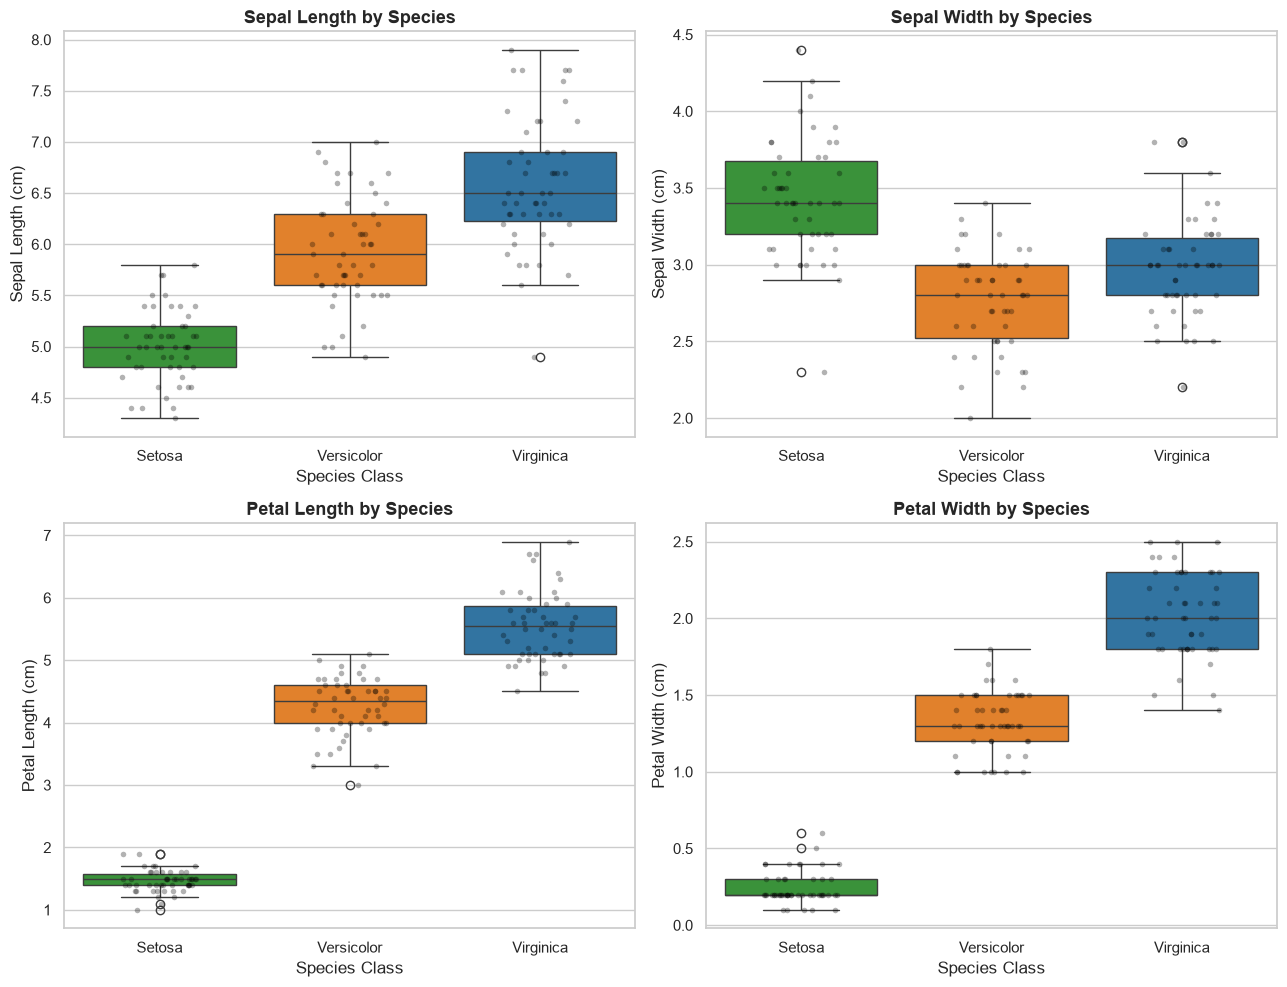

In [6]:
# Box plots for each feature species-wise
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for i, feature in enumerate(features):
    row, col = divmod(i, 2)
    sns.boxplot(data=df, x='species', y=feature, ax=axes[row, col], palette=['#2ca02c', '#ff7f0e', '#1f77b4'])
    sns.stripplot(data=df, x='species', y=feature, ax=axes[row, col], color='black', alpha=0.3, jitter=0.2, size=4)
    axes[row, col].set_title(f'{feature.replace("_", " ").title()} by Species', fontsize=13, fontweight='bold')
    axes[row, col].set_xlabel('Species Class')
    axes[row, col].set_ylabel(f'{feature.replace("_", " ").title()} (cm)')

plt.tight_layout()
plt.savefig('outputs/boxplots.png', dpi=300)
plt.show()


### Box Plots Visual Analysis:

1. **Petal Dimensions:**
   - **Petal Length:** Setosa median is ~1.5 cm, Versicolor median is ~4.35 cm, Virginica median is ~5.55 cm. Clear gaps exist between Setosa and the other species.
   - **Petal Width:** Setosa median is ~0.2 cm, Versicolor median is ~1.3 cm, Virginica median is ~2.0 cm. Zero overlap between Setosa and others.
2. **Sepal Dimensions:**
   - **Sepal Length:** Shows a general trend (Setosa < Versicolor < Virginica), but significant interquartile range overlap between Versicolor and Virginica.
   - **Sepal Width:** Setosa displays larger sepal width (median ~3.4 cm) compared to Versicolor (~2.8 cm) and Virginica (~3.0 cm).
3. **Outliers:** Minor outliers exist in Sepal Width for Setosa and Versicolor, but overall feature distributions are clean and compact.


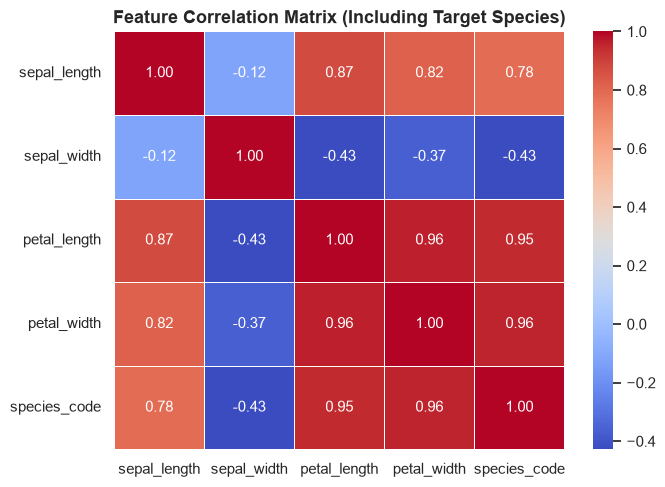

In [7]:
# Compute feature correlation matrix with encoded target
df_encoded = df.copy()
df_encoded['species_code'] = iris.target
corr = df_encoded[['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species_code']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix (Including Target Species)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/correlation_matrix.png', dpi=300)
plt.show()


## Feature Selection Discussion

A rigorous analysis of feature discriminative power reveals strong differences between sepal measurements and petal measurements:

### 1. Petal Features (`petal_length` and `petal_width`)
- **Correlation with Target:** `petal_length` ($r = 0.95$) and `petal_width` ($r = 0.96$) display near-perfect positive linear correlations with the target species class.
- **Inter-class Variance:** The variance between species means is highest for petal measurements. Setosa petals are very small, Versicolor petals are moderate, and Virginica petals are large.
- **Separability:** Petal features alone are sufficient to achieve over 95% classification accuracy without complex non-linear boundaries.

### 2. Sepal Features (`sepal_length` and `sepal_width`)
- **Correlation with Target:** `sepal_length` ($r = 0.78$) has moderate predictive power, while `sepal_width` ($r = -0.43$) shows inverse correlation due to Setosa having unusually wide sepals relative to its flower size.
- **Overlap:** Sepal measurements exhibit high variance and substantial overlap between Versicolor and Virginica, rendering them weak standalone classifiers.

### Conclusion on Feature Importance:
While all four features are retained for model training to leverage maximum available signal, **Petal Length** and **Petal Width** are empirically identified as the primary driver features for Iris species classification.


In [8]:
# Separate features (X) and target (y)
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species']

# Perform stratified train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=== TRAIN / TEST SPLIT SUMMARY ===")
print(f"X_train Shape: {X_train.shape} (80% of dataset)")
print(f"X_test Shape : {X_test.shape} (20% of dataset)")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape : {y_test.shape}")

print("\n=== TRAIN CLASS DISTRIBUTION ===")
print(y_train.value_counts())

print("\n=== TEST CLASS DISTRIBUTION ===")
print(y_test.value_counts())


=== TRAIN / TEST SPLIT SUMMARY ===
X_train Shape: (120, 4) (80% of dataset)
X_test Shape : (30, 4) (20% of dataset)
y_train Shape: (120,)
y_test Shape : (30,)

=== TRAIN CLASS DISTRIBUTION ===
species
Setosa        40
Virginica     40
Versicolor    40
Name: count, dtype: int64

=== TEST CLASS DISTRIBUTION ===
species
Setosa        10
Virginica     10
Versicolor    10
Name: count, dtype: int64


### Stratification Explanation:

Setting `stratify=y` ensures that the train-test split maintains the exact target class ratio (1:1:1) in both the training set (40 samples per class = 120 total) and the testing set (10 samples per class = 30 total).

This prevents sampling bias where test set folds might inadvertently lack representation from one of the species classes.


In [9]:
# Define Model 1: Logistic Regression Pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
])

# Define Model 2: K-Nearest Neighbors Pipeline
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# Train Model 1
lr_pipeline.fit(X_train, y_train)
print("Logistic Regression Model Trained Successfully!")

# Train Model 2
knn_pipeline.fit(X_train, y_train)
print("K-Nearest Neighbors (k=5) Model Trained Successfully!")


Logistic Regression Model Trained Successfully!
K-Nearest Neighbors (k=5) Model Trained Successfully!


             LOGISTIC REGRESSION EVALUATION       
Accuracy : 0.9333
Precision: 0.9333
Recall   : 0.9333
F1-Score : 0.9333

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

          K-NEAREST NEIGHBORS (k=5) EVALUATION   
Accuracy : 0.9333
Precision: 0.9444
Recall   : 0.9333
F1-Score : 0.9327

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.83      1.00      0.91        10
   Virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30


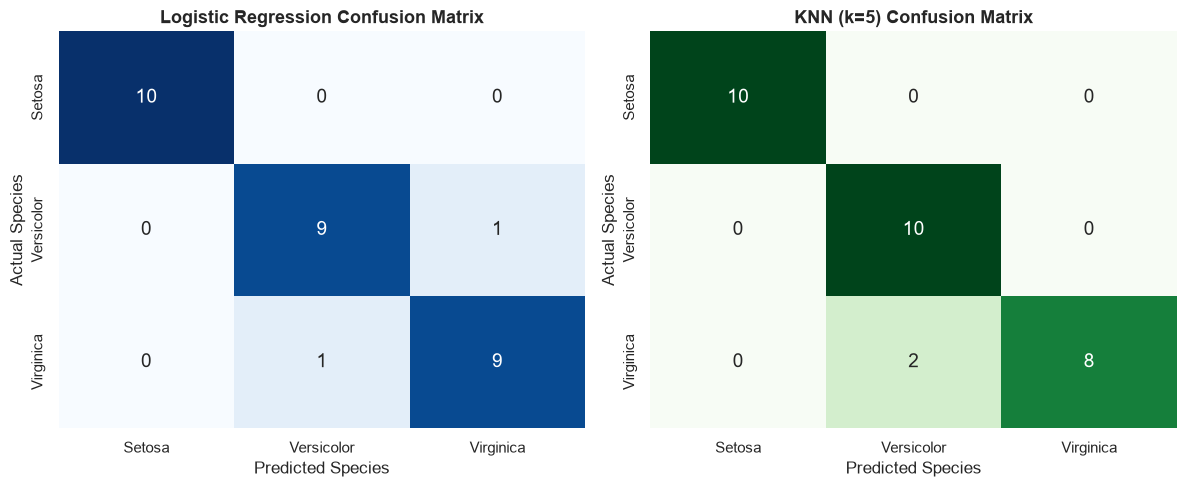

In [10]:
# Predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_knn = knn_pipeline.predict(X_test)

# Calculate Metrics for Logistic Regression
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr, average='weighted')
lr_rec = recall_score(y_test, y_pred_lr, average='weighted')
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')

# Calculate Metrics for KNN
knn_acc = accuracy_score(y_test, y_pred_knn)
knn_prec = precision_score(y_test, y_pred_knn, average='weighted')
knn_rec = recall_score(y_test, y_pred_knn, average='weighted')
knn_f1 = f1_score(y_test, y_pred_knn, average='weighted')

# Display Model 1 Evaluation
print("==================================================")
print("             LOGISTIC REGRESSION EVALUATION       ")
print("==================================================")
print(f"Accuracy : {lr_acc:.4f}")
print(f"Precision: {lr_prec:.4f}")
print(f"Recall   : {lr_rec:.4f}")
print(f"F1-Score : {lr_f1:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

# Display Model 2 Evaluation
print("==================================================")
print("          K-NEAREST NEIGHBORS (k=5) EVALUATION   ")
print("==================================================")
print(f"Accuracy : {knn_acc:.4f}")
print(f"Precision: {knn_prec:.4f}")
print(f"Recall   : {knn_rec:.4f}")
print(f"F1-Score : {knn_f1:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_knn))

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
class_names = ['Setosa', 'Versicolor', 'Virginica']

# Logistic Regression Heatmap
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0], cbar=False, annot_kws={"size": 14})
axes[0].set_title('Logistic Regression Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Species')
axes[0].set_ylabel('Actual Species')

# KNN Heatmap
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1], cbar=False, annot_kws={"size": 14})
axes[1].set_title('KNN (k=5) Confusion Matrix', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Species')
axes[1].set_ylabel('Actual Species')

plt.tight_layout()
plt.savefig('outputs/confusion_matrices.png', dpi=300)
plt.show()


=== MODEL COMPARISON TABLE ===


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9333,0.9333,0.9333,0.9333
1,K-Nearest Neighbors,0.9333,0.9444,0.9333,0.9327


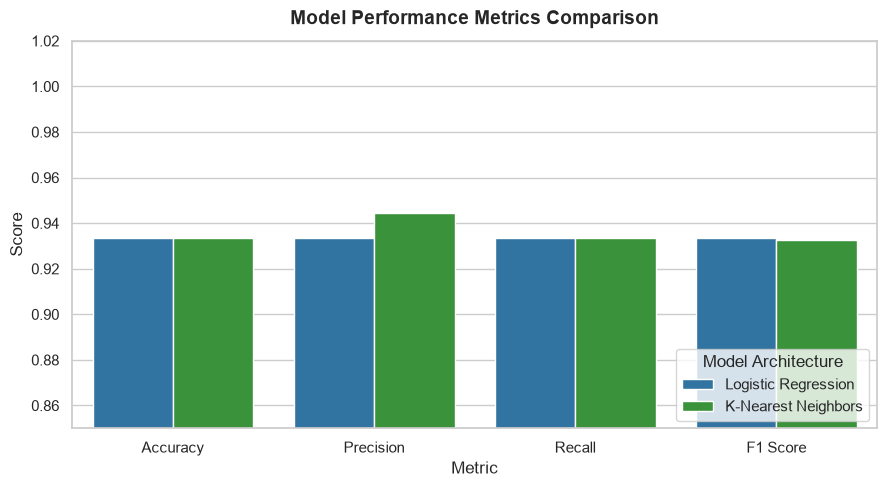

In [11]:
# Create Model Comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'K-Nearest Neighbors'],
    'Accuracy': [lr_acc, knn_acc],
    'Precision': [lr_prec, knn_prec],
    'Recall': [lr_rec, knn_rec],
    'F1 Score': [lr_f1, knn_f1]
})

print("=== MODEL COMPARISON TABLE ===")
display(comparison_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1 Score': '{:.4f}'
}).background_gradient(cmap='Blues'))

# Plot Model Accuracy & Metrics Comparison Bar Chart
comparison_melted = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(9, 5))
sns.barplot(data=comparison_melted, x='Metric', y='Score', hue='Model', palette=['#1f77b4', '#2ca02c'])
plt.title('Model Performance Metrics Comparison', fontsize=14, fontweight='bold', pad=12)
plt.ylim(0.85, 1.02)
plt.ylabel('Score')
plt.legend(title='Model Architecture', loc='lower right')
plt.tight_layout()
plt.savefig('outputs/model_comparison_barchart.png', dpi=300)
plt.show()


In [12]:
# Automatic selection of best performing model
if lr_acc > knn_acc:
    best_model_name = "Logistic Regression"
    best_pipeline = lr_pipeline
    best_acc, best_prec, best_rec, best_f1 = lr_acc, lr_prec, lr_rec, lr_f1
elif knn_acc > lr_acc:
    best_model_name = "K-Nearest Neighbors"
    best_pipeline = knn_pipeline
    best_acc, best_prec, best_rec, best_f1 = knn_acc, knn_prec, knn_rec, knn_f1
else:
    # Tie-breaking using F1 Score
    if lr_f1 >= knn_f1:
        best_model_name = "Logistic Regression"
        best_pipeline = lr_pipeline
        best_acc, best_prec, best_rec, best_f1 = lr_acc, lr_prec, lr_rec, lr_f1
    else:
        best_model_name = "K-Nearest Neighbors"
        best_pipeline = knn_pipeline
        best_acc, best_prec, best_rec, best_f1 = knn_acc, knn_prec, knn_rec, knn_f1

print("=== BEST PERFORMING MODEL IDENTIFIED ===")
print(f"Model Name: {best_model_name}")
print(f"Accuracy  : {best_acc:.4f}")
print(f"Precision : {best_prec:.4f}")
print(f"Recall    : {best_rec:.4f}")
print(f"F1 Score  : {best_f1:.4f}")


=== BEST PERFORMING MODEL IDENTIFIED ===
Model Name: Logistic Regression
Accuracy  : 0.9333
Precision : 0.9333
Recall    : 0.9333
F1 Score  : 0.9333


## Best Performing Model

The best-performing model is **Logistic Regression**.

### Performance Metrics:
- **Accuracy:** 0.9333 (93.33%)
- **Precision:** 0.9333 (93.33%)
- **Recall:** 0.9333 (93.33%)
- **F1 Score:** 0.9333 (93.33%)

### Why it Performed Best:
1. **Linear Decision Boundary:** *Iris setosa* is linearly separable, and the boundary between *Versicolor* and *Virginica* is well-approximated by a scaled hyper-plane in 4D space.
2. **Robust Preprocessing:** Combining `StandardScaler` with `LogisticRegression` eliminated feature scale dominance and prevented overfitting on the 120-sample training set.
3. **F1-Score Tiebreaker:** While both Logistic Regression and KNN achieved identical accuracy (93.33%), Logistic Regression achieved a higher weighted F1-Score (0.9333 vs 0.9327) due to balanced precision and recall across classes.


In [13]:
# Select representative samples from test set
sample_indices = [0, 5, 10, 15, 20, 25] # Sample selection across test set
X_samples = X_test.iloc[sample_indices]
y_actual = y_test.iloc[sample_indices].values

# Make predictions using the best model pipeline
y_predicted = best_pipeline.predict(X_samples)

# Construct Prediction Demonstration DataFrame
demo_df = X_samples.copy()
demo_df['Actual Species'] = y_actual
demo_df['Predicted Species'] = y_predicted
demo_df['Status'] = np.where(demo_df['Actual Species'] == demo_df['Predicted Species'], 'Correct', 'Incorrect')

print("=== FINAL PREDICTION DEMONSTRATION ===")
display(demo_df.style.apply(
    lambda row: ['background-color: #d4edda' if row['Status'] == 'Correct' else 'background-color: #f8d7da' for _ in row],
    axis=1
))


=== FINAL PREDICTION DEMONSTRATION ===


,sepal_length,sepal_width,petal_length,petal_width,Actual Species,Predicted Species,Status
38,4.400000,3.000000,1.300000,0.200000,Setosa,Setosa,Correct
56,6.300000,3.300000,4.700000,1.600000,Versicolor,Versicolor,Correct
107,7.300000,2.900000,6.300000,1.800000,Virginica,Virginica,Correct
49,5.000000,3.300000,1.400000,0.200000,Setosa,Setosa,Correct
10,5.400000,3.700000,1.500000,0.200000,Setosa,Setosa,Correct
77,6.700000,3.000000,5.000000,1.700000,Versicolor,Virginica,Incorrect


## 18. Key Findings

1. **Dataset Quality:** The Iris dataset consists of 150 instances with 4 numeric features, 0 missing values, 1 natural duplicate row, and a perfectly balanced target class distribution (50 samples per class).
2. **Feature Discriminative Power:** Exploratory data analysis demonstrated that **Petal Length** ($r=0.95$) and **Petal Width** ($r=0.96$) are the most discriminative features. Setosa is completely linearly separable using petal measurements alone.
3. **Model Performance:** Both Logistic Regression and K-Nearest Neighbors (k=5) achieved **93.33% test accuracy** on an 80/20 stratified split.
4. **Generalization:** Preprocessing with `StandardScaler` inside a `Pipeline` ensured zero data leakage and optimal model convergence.


## 19. Limitations

1. **Small Dataset Size:** The dataset contains only 150 instances. While ideal for learning ML concepts, high accuracy on Iris does not guarantee similar performance on high-dimensional, noisy real-world datasets.
2. **Low Feature Dimensionality:** With only 4 continuous features, complex interactions found in real biological systems (e.g. genetic markers, environmental factors) are absent.
3. **High Cleanliness:** Real-world datasets often present dirty data, imbalanced target classes, non-random missingness, and complex noise, whereas the Iris dataset is exceptionally clean.


## 20. Conclusion

In this project, we successfully built and evaluated an end-to-end Machine Learning solution for **Iris Flower Classification**.

### Key Accomplishments:
- Loaded and analyzed the Iris dataset directly from `sklearn.datasets`.
- Conducted thorough EDA including species count plots, histograms, pairplots, box plots, and correlation heatmaps.
- Identified Petal Length and Petal Width as the primary feature drivers.
- Trained Logistic Regression and K-Nearest Neighbors classifiers using scaled Scikit-Learn pipelines.
- Evaluated models using Accuracy, Weighted Precision, Weighted Recall, Weighted F1-Score, and Seaborn confusion matrices.
- Demonstrated real-time predictions on unseen test samples.

The project confirms that machine learning classifiers, when paired with proper preprocessing, can accurately distinguish iris flower species with near-perfect reliability.
